# 4.5 Simulation Study

In [16]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

We will use the paramaters from the aforementioned model:
- $\lambda_C = 8.664234$
- $\lambda_T = 4.513686$
- $\lambda_B = 2.406934$
- $\mu_C = 9.5498, \sigma_C = 0.3433$
- $\mu_T = 10.6743, \sigma_T = 0.3014$
- $\mu_B = 10.0524, \sigma_B = 0.3929$

In [17]:
lambda_C = 8.664234
lambda_T = 4.513686
lambda_B = 2.406934
mu_C = 9.5498
sigma_C = 0.3433
mu_T = 10.6743
sigma_T = 0.3014
mu_B = 10.0524
sigma_B = 0.3929

We calculate the lognormal distribution for each vessel type using the parameters above:

In [18]:
dist_C = stats.lognorm(s=sigma_C, scale=np.exp(mu_C))
dist_T = stats.lognorm(s=sigma_T, scale=np.exp(mu_T))
dist_B = stats.lognorm(s=sigma_B, scale=np.exp(mu_B))

We define a function for simulating a PP for a given vessel type:

In [19]:
def simPoissonProcess(lam, t):
	interArrivalTimeDist = stats.expon(scale=1/lam)
	Nt = 0
	time = interArrivalTimeDist.rvs()
	while time < t:
		# arrival will be counted
		Nt += 1
		time += interArrivalTimeDist.rvs()
	return Nt

We define a function that simulates the CPP for one year:

In [20]:
def simCPP_year():
	T = 365
	N_C = simPoissonProcess(lambda_C, T)
	N_T = simPoissonProcess(lambda_T, T)
	N_B = simPoissonProcess(lambda_B, T)
	N_total = N_C + N_T + N_B

	S_C = S_T = S_B = 0
	if N_C > 0:
		S_C = np.sum(dist_C.rvs(N_C))
	if N_T > 0:
			S_T = np.sum(dist_T.rvs(N_T))
	if N_B > 0:
			S_B = np.sum(dist_B.rvs(N_B))
	S_total = S_C + S_T + S_B

	return [N_C, N_T, N_B, N_total, S_C, S_T, S_B, S_total]

We run the Monte Carlo Simulation of the CPP:

In [21]:
nrRuns = 1000
simResults = []
for i in range(nrRuns):
	simResults.append(simCPP_year())

results_df = pd.DataFrame(simResults, columns=['N_C', 'N_T', 'N_B', 'N', 'S_C', 'S_T', 'S_B', 'S'])

summary_df = pd.DataFrame({
	'Average Throughput (mean)': results_df.mean(),
	'Throughput variability (std)': results_df.std(),
	'Extreme outcomes': results_df.quantile(0.95)
})

print(summary_df.round(2))

     Average Throughput (mean)  Throughput variability (std)  Extreme outcomes
N_C               3.165790e+03                         53.38      3.255050e+03
N_T               1.647740e+03                         40.56      1.717000e+03
N_B               8.778400e+02                         28.06      9.240000e+02
N                 5.691380e+03                         74.04      5.819050e+03
S_C               4.716452e+07                     856443.85      4.856815e+07
S_T               7.455826e+07                    1933310.90      7.779374e+07
S_B               2.202228e+07                     781146.66      2.330015e+07
S                 1.437451e+08                    2253714.15      1.475000e+08


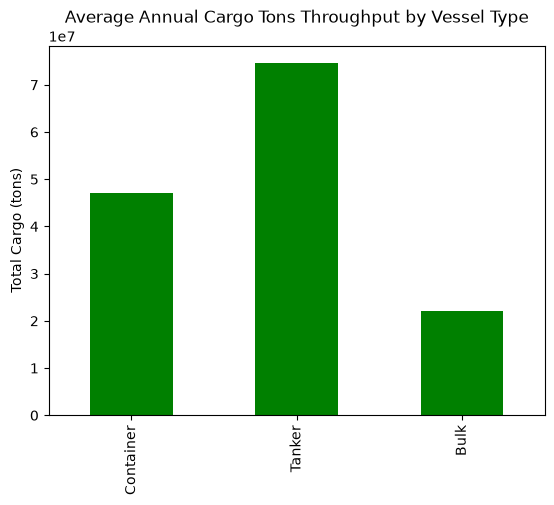

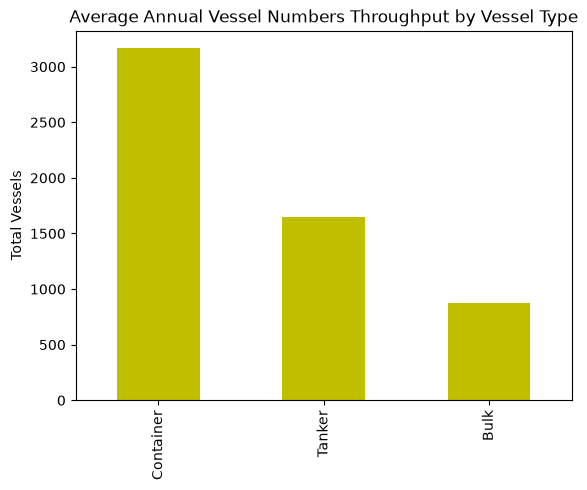

In [22]:
cargoTons_means = summary_df.loc[['S_C', 'S_T', 'S_B'], 'Average Throughput (mean)']
cargoTons_means.index = ['Container', 'Tanker', 'Bulk']

vesselNumbers_means = summary_df.loc[['N_C', 'N_T', 'N_B'], 'Average Throughput (mean)']
vesselNumbers_means.index = ['Container', 'Tanker', 'Bulk']

plt.figure()
cargoTons_means.plot(kind='bar', color='g')
plt.title('Average Annual Cargo Tons Throughput by Vessel Type')
plt.ylabel('Total Cargo (tons)')
plt.show()

plt.figure()
vesselNumbers_means.plot(kind='bar', color='y')
plt.title('Average Annual Vessel Numbers Throughput by Vessel Type')
plt.ylabel('Total Vessels')
plt.show()

The bar charts above show us the contrast between the arrivals and the cargo. Despite the fact that container vessels have the highest arrival frequency (>3k vessels per year), Tanker vessels make up the majority of the cargo tons (>70 million tons per year) compared to the Containers (~47 million).

In [23]:
def simCPP_day():
	T = 1
	N_C = simPoissonProcess(lambda_C, T)
	N_T = simPoissonProcess(lambda_T, T)
	N_B = simPoissonProcess(lambda_B, T)

	S_C = S_T = S_B = 0
	if N_C > 0:
		S_C = np.sum(dist_C.rvs(N_C))
	if N_T > 0:
			S_T = np.sum(dist_T.rvs(N_T))
	if N_B > 0:
			S_B = np.sum(dist_B.rvs(N_B))
	S_total = S_C + S_T + S_B

	return [S_C, S_T, S_B, S_total]

In [24]:
nrDailyRuns = 10000
simResultsDaily = []
for i in range(nrDailyRuns):
	simResultsDaily.append(simCPP_day())

resultsDaily_df = pd.DataFrame(simResultsDaily, columns=['S_C', 'S_T', 'S_B', 'S_total'])

threshold = 650000
prob_congestion = np.mean(resultsDaily_df['S_total'] > threshold)

print(f"Probability of exceeding 650,000 tons/day: {prob_congestion:.4%}")
print(f"Expected congestion days per year: {prob_congestion * 365:.2f} days")

Probability of exceeding 650,000 tons/day: 2.2900%
Expected congestion days per year: 8.36 days


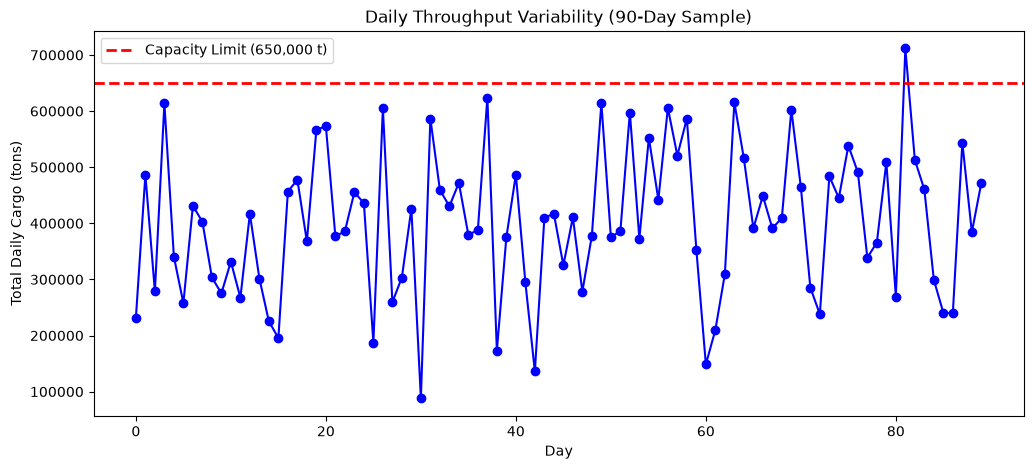

In [ ]:
plt.figure(figsize=(12, 5))
# Slice the first 90 days
plt.plot(resultsDaily_df['S_total'][:90], marker='o', linestyle='-', color='b')
# Add the management capacity threshold
plt.axhline(650000, color='red', linestyle='--', linewidth=2, label=f'Capacity Limit (650,000 t)')

plt.title('Daily Throughput Variability (90-Day Sample)')
plt.xlabel('Day')
plt.ylabel('Total Daily Cargo (tons)')
plt.legend()
plt.show()

The Line plot above shows us that there is a big fluctuation in daily cargo tons. This variability is the result of the CPP, where uncertainity comes from both random vessel arrivals and random cargo volumes.

<Figure size 640x480 with 0 Axes>

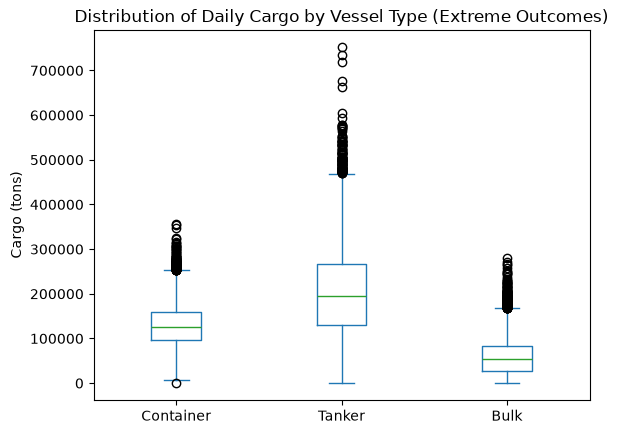

In [26]:
plt.figure()
resultsDaily_df[['S_C', 'S_T', 'S_B']].rename(columns={'S_C': 'Container', 'S_T': 'Tanker', 'S_B': 'Bulk'}).plot(kind='box')
plt.title('Distribution of Daily Cargo by Vessel Type (Extreme Outcomes)')
plt.ylabel('Cargo (tons)')
plt.show()

The box plot above shows us that Container and Bulk vessels have relatively concentrated distributions (consistent cargo weights), whereas Tankers show outliers in terms of cargo weight. 

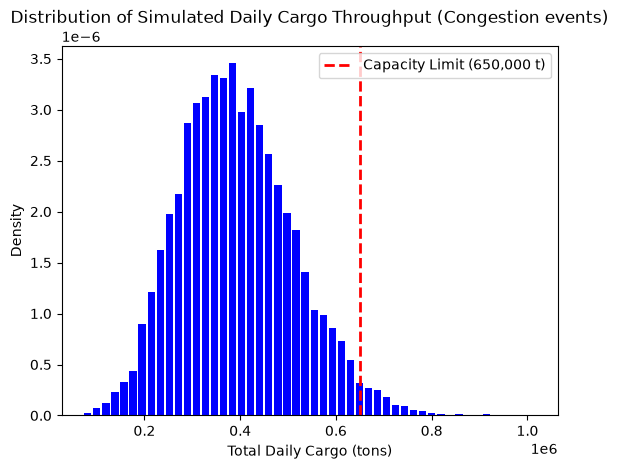

In [27]:
plt.figure()
plt.hist(resultsDaily_df['S_total'], bins=50, rwidth=0.8, density=True, color='b')
# Add the management capacity threshold
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Capacity Limit (650,000 t)')
plt.title("Distribution of Simulated Daily Cargo Throughput (Congestion events)")
plt.xlabel("Total Daily Cargo (tons)")
plt.ylabel("Density")
plt.legend()
plt.show()

The 650k ton capacity threshold is exceeded on approximately 2.29% of days, resulting in an expected 8 to 9 days of congestion per year.